### Simple Linear Regression with Closed-Form Solution (Normal Equations)

$$ w = \frac{\sum_{i=1}^n x_i y_i - \frac{1}{n}\left(\sum_{i=1}^n x_i\right)\left(\sum_{i=1}^n y_i\right)}{\sum_{i=1}^n x_i^2 - \frac{1}{n}\left(\sum_{i=1}^n x_i\right)^2} $$

$$ b = \frac{1}{n}\sum_{i=1}^n y_i - \frac{w}{n}\sum_{i=1}^n x_i $$


Modelo: y = 5.222151077447229 + 1.9936935021402038 * x


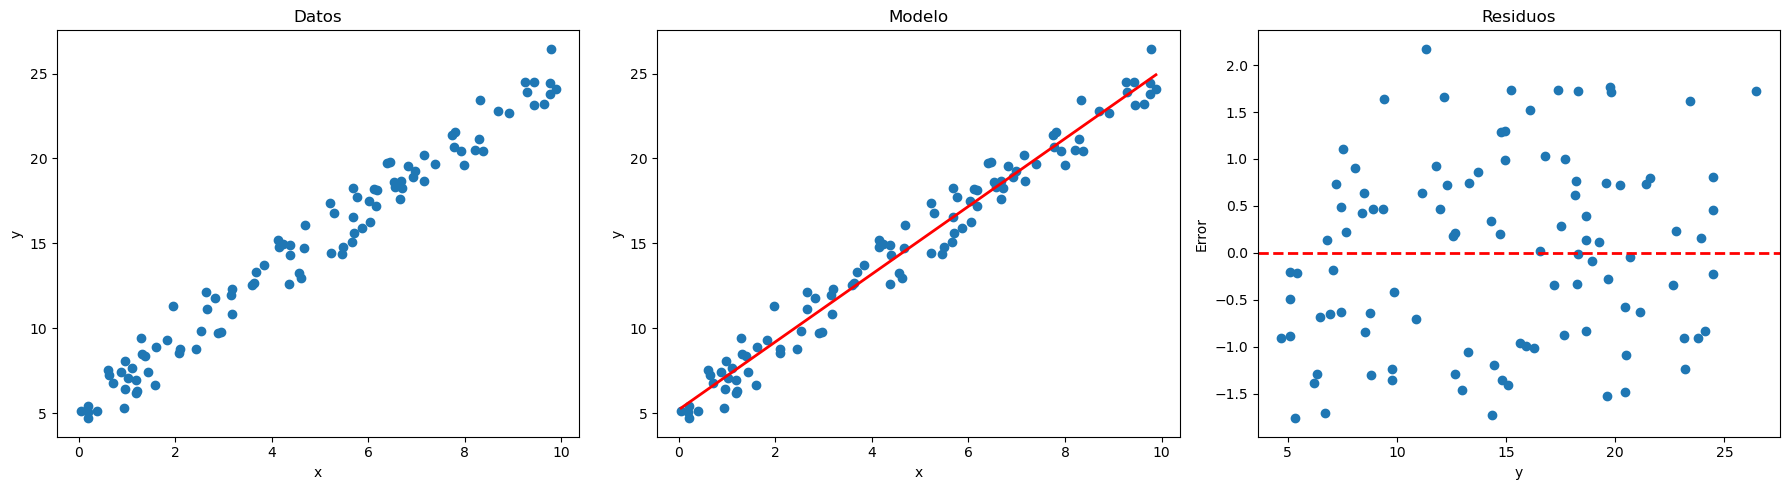

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Data generation
x = np.random.uniform(0, 10, 100)
y = 5 + 2*x + np.random.normal(0, 1, 100)

# Compute coefficients (closed-form)
n = len(x)
w = ((x*y).sum() - (1./n)*x.sum()*y.sum()) / ((x*x).sum() - (1./n)*(x.sum()**2))
b = (1./n)*y.sum() - (w/n)*x.sum()
print("Modelo: y =", b, "+", w, "* x")

# Predictions and residuals
y_pred = w*x + b
r = y - y_pred

# ---- subplots ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Datos originales
axes[0].scatter(x, y)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Datos')

# línea de regression
idx = np.argsort(x) 
axes[1].scatter(x, y)
axes[1].plot(x[idx], y_pred[idx], color='red', linewidth=2)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Modelo')

# Residuos
axes[2].scatter(y, r)
axes[2].axhline(0, color='red', linestyle='--', linewidth=2)
axes[2].set_xlabel('y')
axes[2].set_ylabel('Error')
axes[2].set_title('Residuos')

plt.tight_layout()
plt.show()


# [Diabetes dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset)

Diabetes dataset
442 samples (rows), 10 features (columns)

Features:
- age – Age of the patient
- sex – Sex of the patient
- bmi – Body mass index.
- bp – Average blood pressure.
- s1 – tc, total serum cholesterol.
- s2 – ldl, low-density lipoproteins.
- s3 – hdl, high-density lipoproteins.
- s4 – tch, total cholesterol / HDL.
- s5 – ltg, possibly log of serum triglycerides level.
- s6 – glu, blood sugar level.

Target Variable:

A quantitative measure of diabetes progression one year after the first observation..


### Case 1. Training and validation with the same dataset (Not recommended, overestimates performance)

The following cell trains and validates a linear regression model using the same dataset. This is not recommended, since the performance estimate is optimistic.

In [3]:
from sklearn import datasets
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


diabetes = datasets.load_diabetes()
x = diabetes.data
y = diabetes.target
features = diabetes.feature_names
n_features = len(features)

print(f"# features: {n_features}")

regr = LinearRegression()
regr.fit(x, y)

print("Coeficientes del modelo: \n", regr.coef_)

y_pred = regr.predict(x)
print('MSE: \n', mean_squared_error(y, y_pred))
print('MAE: \n', mean_absolute_error(y, y_pred))
print("R^2: \n", r2_score(y, y_pred))


# features: 10
Coeficientes del modelo: 
 [ -10.0098663  -239.81564367  519.84592005  324.3846455  -792.17563855
  476.73902101  101.04326794  177.06323767  751.27369956   67.62669218]
MSE: 
 2859.6963475867506
MAE: 
 43.27745202531507
R^2: 
 0.5177484222203498


### Case 2. Train and evaluate on separate sets (train, test)

In [4]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# 1. Load dataset
diabetes = load_diabetes()
x = diabetes.data
y = diabetes.target
features = diabetes.feature_names
n_features = len(features)
print(f"# features: {n_features}")

# 2. Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=0
)

# 4. Entrenar el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Predicciones y evaluación
y_pred = model.predict(X_test)
print("Intercepto:", model.intercept_)
for name, coef in zip(features, model.coef_):
    print(f"{name}: {coef:.4f}")
print('-'*10)
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

# features: 10
Intercepto: 152.5380470138517
age: -35.5503
sex: -243.1651
bmi: 562.7623
bp: 305.4635
s1: -662.7029
s2: 324.2074
s3: 24.7488
s4: 170.3250
s5: 731.6374
s6: 43.0309
----------
MSE: 3424.2593342986925
MAE: 46.17358500370479
R²: 0.3322332173106183


### Case 3. Use K-Fold cross-validation in a manual loop.

In [5]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# 1. Load dataset
diabetes = load_diabetes()
x = diabetes.data
y = diabetes.target
features = diabetes.feature_names
n_features = len(features)
print(f"# features: {n_features}")

n_folds = 5
kf = KFold(n_splits=n_folds, shuffle = True, random_state=0)

mse = 0
mae = 0
r2 = 0
for k, (train_index, test_index) in enumerate(kf.split(x)):
    print(f'Iteración de k-fold: {k+1}')
    # Training phase
    x_train = x[train_index, :]
    y_train = y[train_index]

    regr_cv = LinearRegression()
    regr_cv.fit(x_train, y_train)

    # Test phase
    x_test = x[test_index, :]
    y_test = y[test_index]    

    y_pred = regr_cv.predict(x_test)

    # Calculate MSE and R^2    
    mse_i = mean_squared_error(y_test, y_pred)
    print('\t mse = ', mse_i)
    
    mae_i = mean_absolute_error(y_test, y_pred)
    print('\t mae = ', mae_i)

    r2_i = r2_score(y_test, y_pred)
    print('\t r^2= ', r2_i)

    mse += mse_i
    mae += mae_i 
    r2 += r2_i 


print("\nMetricas promedio: \n")

mse = mse/n_folds
print('MSE = ', mse)

mae = mae/n_folds
print('MAE = ', mae)

r2 = r2/n_folds
print('R^2 = ', r2)



# features: 10
Iteración de k-fold: 1
	 mse =  3424.259334298692
	 mae =  46.17358500370479
	 r^2=  0.3322332173106183
Iteración de k-fold: 2
	 mse =  2890.8945076703667
	 mae =  43.58195742468968
	 r^2=  0.45970425424589056
Iteración de k-fold: 3
	 mse =  2964.580485709375
	 mae =  45.726384700989165
	 r^2=  0.5370636865383391
Iteración de k-fold: 4
	 mse =  2854.937426125663
	 mae =  42.35028879490521
	 r^2=  0.521653908550179
Iteración de k-fold: 5
	 mse =  2753.3208215123823
	 mae =  43.62921474523517
	 r^2=  0.5951198005819458

Metricas promedio: 

MSE =  2977.598515063296
MAE =  44.2922861339048
R^2 =  0.4891549734453946


### Case 4. Use K-Fold cross-validation and the cross_validate function.

1. Investigate the cross_validate function from scikit-learn.
2. Use it to evaluate the model.

In [6]:

# Your code here

### Case 5. Use the cross_val_predict function.

In [7]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

diabetes = load_diabetes()
x = diabetes.data
y = diabetes.target
features = diabetes.feature_names
n_features = len(features)
print(f"# features: {n_features}")

regr = LinearRegression()
y_pred = cross_val_predict(regr, x, y, cv = 5)

print("y_pred shape: ", y_pred.shape)

print('mse = ', mean_squared_error(y, y_pred))
print('mae = ', mean_absolute_error(y, y_pred))
print('r^2= ', r2_score(y, y_pred)) 


# features: 10
y_pred shape:  (442,)
mse =  2992.679946593995
mae =  44.27485590220917
r^2=  0.49532242216821853


# Feature selection using wrapper methods.

### Linear regression with sequential feature selection.

The following cell: 

1. Selects half of the features using a greedy sequential search. 
    - a) Selects half of the features using SequentialFeatureSelector. 
    - b) Evaluates using the training data (not recommended).
    - c) Evaluates using cross-validation (recommended).

2. Use sequential feature selection to determine the optimal number of features.



#### Reduce the number of features by half (incorrect approach).

The problem is that there is data leakage, because feature selection uses the entire dataset before evaluation, producing overly optimistic metrics.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn import linear_model
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SequentialFeatureSelector

diabetes = datasets.load_diabetes()
x = diabetes.data
y = diabetes.target
features = diabetes.feature_names
n_features = len(features)

print("\n ----- Feature selection using 50% of predictors -----")

regr = linear_model.LinearRegression()
fselection = SequentialFeatureSelector(regr, n_features_to_select = 0.5)
fselection.fit(x, y)
print("Selected features: ", fselection.get_feature_names_out())

# Fit model using the new dataset and evaluate MSE, MAE and R^2
x_transformed = fselection.transform(x)
regr.fit(x_transformed, y)
print("Model coefficients: ", regr.coef_)
print("Model intercept: ", regr.intercept_)

y_pred = regr.predict(x_transformed)
print("Evaluation using training data (not recommended): ")
print('MSE: ', mean_squared_error(y, y_pred))
print("MAE: ", mean_absolute_error(y, y_pred))
print("R^2: ", r2_score(y, y_pred))



 ----- Feature selection using 50% of predictors -----
Selected features:  ['x1' 'x2' 'x3' 'x6' 'x8']
Model coefficients:  [-235.77241318  523.56778633  326.23106396 -289.11483015  474.29023146]
Model intercept:  152.13348416289602
Evaluation using training data (not recommended): 
MSE:  2913.758270125212
MAE:  43.76138263316659
R^2:  0.5086315635496816


#### Reduce the number of features by half using cross-validation (correct approach).

This is the correct approach to avoid data leakage, since feature selection is performed only using the training data. The evaluation is carried out on a separate test set.

In [9]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn import linear_model
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SequentialFeatureSelector

diabetes = datasets.load_diabetes()
x = diabetes.data
y = diabetes.target
features = diabetes.feature_names
n_features = len(features)

mse_cv = []
mae_cv = []
r2_cv = []

kf = KFold(n_splits=5, shuffle = True)

for train_index, test_index in kf.split(x):
    
    # Training phase
    x_train = x[train_index, :]
    y_train = y[train_index]     

    regr_cv = linear_model.LinearRegression()

    fselection_cv = SequentialFeatureSelector(regr_cv, n_features_to_select=0.5)
    fselection_cv.fit(x_train, y_train)
    x_train = fselection_cv.transform(x_train)

    regr_cv.fit(x_train, y_train)

    # Test phase
    x_test = fselection_cv.transform(x[test_index, :])
    y_test = y[test_index]
    y_pred = regr_cv.predict(x_test)
    
    mse_i = mean_squared_error(y_test, y_pred)
    mse_cv.append(mse_i)
    
    mae_i = mean_absolute_error(y_test, y_pred)
    mae_cv.append(mae_i)

    r2_i = r2_score(y_test, y_pred)    
    r2_cv.append(r2_i)      
    
print("Evaluation using cross-validation (recommended): ")
print('MSE:', np.average(mse_cv), '  MAE:', np.average(mae_cv),'  R^2:', np.average(r2_cv))

Evaluation using cross-validation (recommended): 
MSE: 3041.7585315318984   MAE: 44.78537176470677   R^2: 0.4849275841241947


#### Find the optimal number of features

---- n features = 1
MSE: 4093.236824731904   MAE: 52.73641671218636   R^2: 0.30350685945740385
---- n features = 2
MSE: 3245.4392006491516   MAE: 47.123155295226134   R^2: 0.4456307876417333
---- n features = 3
MSE: 3147.2404832080592   MAE: 46.341964621977894   R^2: 0.45262938892643323
---- n features = 4
MSE: 3219.7087249490296   MAE: 46.4709398065639   R^2: 0.4516037472067044
---- n features = 5
MSE: 3059.371907912727   MAE: 44.87826465237951   R^2: 0.4770995251388614
---- n features = 6
MSE: 3034.3039683589027   MAE: 44.64087942260572   R^2: 0.4878635134645629
---- n features = 7
MSE: 3004.812014352553   MAE: 44.247916482186184   R^2: 0.48911421067667815
---- n features = 8
MSE: 3097.857464364655   MAE: 45.298754889720456   R^2: 0.45315767713815164
---- n features = 9
MSE: 3026.267921057004   MAE: 44.39910748739436   R^2: 0.4789267551623556
Optimal number of features:  7


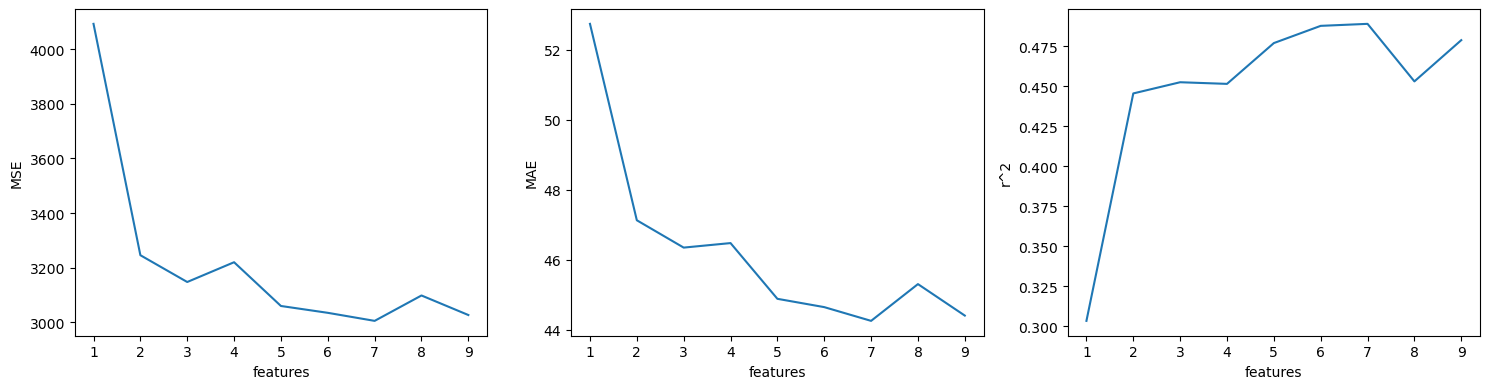

Selected features:  ['x1' 'x2' 'x3' 'x4' 'x5' 'x6' 'x8']
Model coefficients:  [-229.39094705  529.13049183  328.2863938  -627.3116484   427.91955305
  -58.33938198  749.17477877]
Model intercept:  152.13348416289597


In [10]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn import linear_model
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SequentialFeatureSelector

diabetes = datasets.load_diabetes()
x = diabetes.data
y = diabetes.target
features = diabetes.feature_names
n_features = len(features)

n_feats = [1, 2, 3, 4, 5, 6, 7, 8, 9]

mse_nfeat = []
mae_nfeat = []
r2_nfeat = []
for n_feat in n_feats:
    print('---- n features =', n_feat)
    
    mse_cv = []
    mae_cv = []
    r2_cv = []

    kf = KFold(n_splits=5, shuffle = True)

    for train_index, test_index in kf.split(x):
    
        # Training phase
        x_train = x[train_index, :]
        y_train = y[train_index]     

        regr_cv = linear_model.LinearRegression()

        fselection_cv = SequentialFeatureSelector(regr_cv, n_features_to_select=n_feat)
        fselection_cv.fit(x_train, y_train)
        x_train = fselection_cv.transform(x_train)

        regr_cv.fit(x_train, y_train)

        # Test phase
        x_test = fselection_cv.transform(x[test_index, :])
        y_test = y[test_index]
        y_pred = regr_cv.predict(x_test)
    
        mse_i = mean_squared_error(y_test, y_pred)
        mse_cv.append(mse_i)
    
        mae_i = mean_absolute_error(y_test, y_pred)
        mae_cv.append(mae_i)

        r2_i = r2_score(y_test, y_pred)    
        r2_cv.append(r2_i)      
    

    mse = np.average(mse_cv)
    mse_nfeat.append(mse)
    
    mae = np.average(mae_cv)
    mae_nfeat.append(mae)
    
    r2 = np.average(r2_cv)
    r2_nfeat.append(r2)
    
    print('MSE:', mse, '  MAE:', mae,'  R^2:', r2)

opt_index = np.argmin(mse_nfeat)
opt_features = n_feats[opt_index]
print("Optimal number of features: ", opt_features)

fig, axs = plt.subplots(1, 3, figsize=(15, 4), tight_layout=True)

axs[0].plot(n_feats, mse_nfeat)
axs[0].set_xlabel("features")
axs[0].set_ylabel("MSE")

axs[1].plot(n_feats, mae_nfeat)
axs[1].set_xlabel("features")
axs[1].set_ylabel("MAE")

axs[2].plot(n_feats, r2_nfeat)
axs[2].set_xlabel("features")
axs[2].set_ylabel("r^2")

plt.show()

# Fit model with optimal number of features
regr = linear_model.LinearRegression()
fselection = SequentialFeatureSelector(regr, n_features_to_select = opt_features)
fselection.fit(x, y)

print("Selected features: ", fselection.get_feature_names_out())

x_transformed = fselection.transform(x)
regr.fit(x_transformed, y)
print("Model coefficients: ", regr.coef_)
print("Model intercept: ", regr.intercept_)


### Linear regression with backward feature selection

1. Starts with all features.
2. Trains a model, for example, LinearRegression, RandomForest, SVC, etc.
3. Computes the importance of each feature, based on the model coefficients or attributes.
4. Removes the least important feature or features.
5. Repeats the process recursively until only the desired features remain, as specified by n_features_to_select.



In [11]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn import linear_model
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import RFE

# Import Diabetes dataset
diabetes = datasets.load_diabetes()
x = diabetes.data
y = diabetes.target
features = diabetes.feature_names
n_features = len(features)

# Evaluate model using cross validation
mse_cv = []
mae_cv = []
r2_cv = []

kf = KFold(n_splits=5, shuffle = True)

for train_index, test_index in kf.split(x):
    
    # Training phase
    x_train = x[train_index, :]
    y_train = y[train_index]     

    regr_cv = linear_model.LinearRegression()

    fselection_cv = RFE(regr_cv, n_features_to_select=0.5)
    fselection_cv.fit(x_train, y_train)
    x_train = fselection_cv.transform(x_train)

    regr_cv.fit(x_train, y_train)

    # Test phase
    x_test = fselection_cv.transform(x[test_index, :])
    y_test = y[test_index]
    y_pred = regr_cv.predict(x_test)
    
    mse_i = mean_squared_error(y_test, y_pred)
    mse_cv.append(mse_i)
    
    mae_i = mean_absolute_error(y_test, y_pred)
    mae_cv.append(mae_i)

    r2_i = r2_score(y_test, y_pred)    
    r2_cv.append(r2_i)    

print('MSE:', np.average(mse_cv), '  MAE:', np.average(mae_cv),'  R^2:', np.average(r2_cv))

MSE: 3067.698676923422   MAE: 45.15657870539559   R^2: 0.47770876426178166


Find the optimal number of features using a recursive method.

---- n features = 1
MSE: 4061.9578244182458   MAE: 52.93596499441675   R^2: 0.30424904246404166
---- n features = 2
MSE: 3219.8123816530374   MAE: 46.92525085071229   R^2: 0.4552479199053326
---- n features = 3
MSE: 3164.328513956664   MAE: 46.18520378972107   R^2: 0.46052739004055987
---- n features = 4
MSE: 3139.929929676214   MAE: 45.837784165053584   R^2: 0.454621733837069
---- n features = 5
MSE: 3046.0229286649387   MAE: 45.11229146893219   R^2: 0.4829026246610065
---- n features = 6
MSE: 3007.243672487647   MAE: 44.71214549016152   R^2: 0.4770016201306747
---- n features = 7
MSE: 3020.586071158884   MAE: 44.550516930453156   R^2: 0.4784350790013276
---- n features = 8
MSE: 2975.045099510844   MAE: 44.40433388049122   R^2: 0.4972089228911205
---- n features = 9
MSE: 3028.2652077402117   MAE: 44.56924862216104   R^2: 0.48471198962817474
Optimal number of features:  8


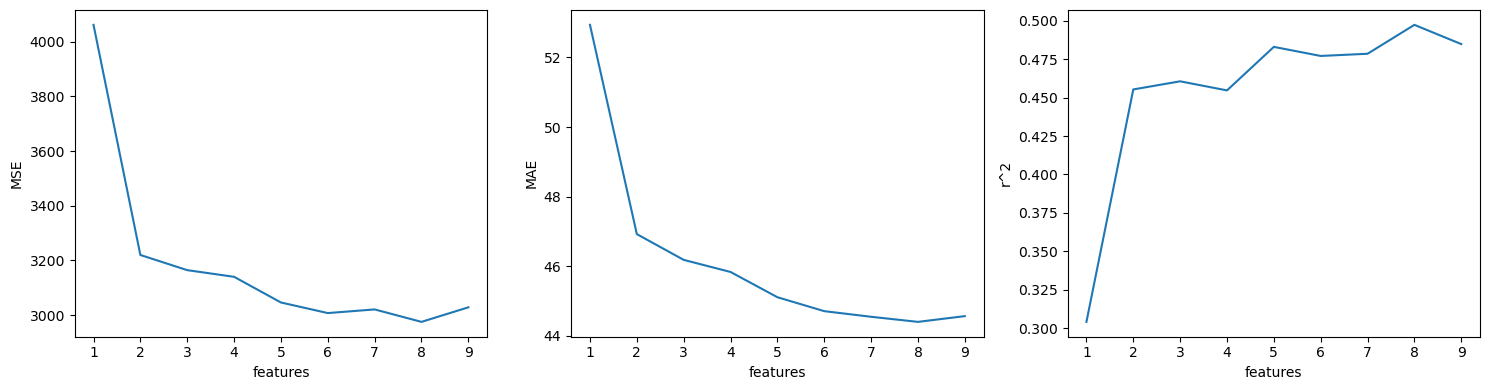

Selected features:  ['x1' 'x2' 'x3' 'x4' 'x5' 'x6' 'x7' 'x8']
Model coefficients:  [-235.4943705   530.09715636  334.49185311 -797.00623113  481.80920972
  106.51394406  188.80713993  766.58930094]
Model intercept:  152.13348416289597


In [12]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn import linear_model
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import RFE

# Import Diabetes dataset
diabetes = datasets.load_diabetes()
x = diabetes.data
y = diabetes.target
features = diabetes.feature_names
n_features = len(features)

n_feats = [1, 2, 3, 4, 5, 6, 7, 8, 9]

mse_nfeat = []
mae_nfeat = []
r2_nfeat = []
for n_feat in n_feats:
    print('---- n features =', n_feat)
    
    mse_cv = []
    mae_cv = []
    r2_cv = []

    kf = KFold(n_splits=5, shuffle = True)

    for train_index, test_index in kf.split(x):
    
        # Training phase
        x_train = x[train_index, :]
        y_train = y[train_index]     

        regr_cv = linear_model.LinearRegression()

        fselection_cv = RFE(regr_cv, n_features_to_select=n_feat)
        fselection_cv.fit(x_train, y_train)
        x_train = fselection_cv.transform(x_train)

        regr_cv.fit(x_train, y_train)

        # Test phase
        x_test = fselection_cv.transform(x[test_index, :])
        y_test = y[test_index]
        y_pred = regr_cv.predict(x_test)
    
        mse_i = mean_squared_error(y_test, y_pred)
        mse_cv.append(mse_i)
    
        mae_i = mean_absolute_error(y_test, y_pred)
        mae_cv.append(mae_i)

        r2_i = r2_score(y_test, y_pred)    
        r2_cv.append(r2_i)      
    

    mse = np.average(mse_cv)
    mse_nfeat.append(mse)
    
    mae = np.average(mae_cv)
    mae_nfeat.append(mae)
    
    r2 = np.average(r2_cv)
    r2_nfeat.append(r2)
    
    print('MSE:', mse, '  MAE:', mae,'  R^2:', r2)

opt_index = np.argmin(mse_nfeat)
opt_features = n_feats[opt_index]
print("Optimal number of features: ", opt_features)

fig, axs = plt.subplots(1, 3, figsize=(15, 4), tight_layout=True)
axs[0].plot(n_feats, mse_nfeat)
axs[0].set_xlabel("features")
axs[0].set_ylabel("MSE")

axs[1].plot(n_feats, mae_nfeat)
axs[1].set_xlabel("features")
axs[1].set_ylabel("MAE")

axs[2].plot(n_feats, r2_nfeat)
axs[2].set_xlabel("features")
axs[2].set_ylabel("r^2")

plt.show()

regr = linear_model.LinearRegression()
fselection = RFE(regr, n_features_to_select = opt_features)
fselection.fit(x, y)

print("Selected features: ", fselection.get_feature_names_out())

x_transformed = fselection.transform(x)
regr.fit(x_transformed, y)
print("Model coefficients: ", regr.coef_)
print("Model intercept: ", regr.intercept_)


### Linear regression with filter-based feature selection.

1. Use a filter method that uses Pearson correlation to identify the 5 best features according to this criterion.
2. Find the optimal number of features using the filter method.


---- n features = 1
MSE: 3908.588228095934   MAE: 51.90949086392874   R^2: 0.3363584886022326
---- n features = 2
MSE: 3229.7854582604014   MAE: 46.90912358288871   R^2: 0.45496645514933276
---- n features = 3
MSE: 3213.959569092277   MAE: 46.9177859080984   R^2: 0.45011522758596306
---- n features = 4
MSE: 3153.1611130654405   MAE: 46.41693297184001   R^2: 0.4575486323083463
---- n features = 5
MSE: 3143.351628678521   MAE: 46.19275078648642   R^2: 0.4598001817488898
---- n features = 6
MSE: 3059.2613328892835   MAE: 45.25161287471471   R^2: 0.47818266601203946
---- n features = 7
MSE: 3118.3081331829603   MAE: 45.68582511394983   R^2: 0.4690001564114198
---- n features = 8
MSE: 3103.2927712439305   MAE: 45.49503355837732   R^2: 0.47039765622428653
---- n features = 9
MSE: 3016.0064516046195   MAE: 44.558031848684486   R^2: 0.48045092115440236
Optimal number of features:  9


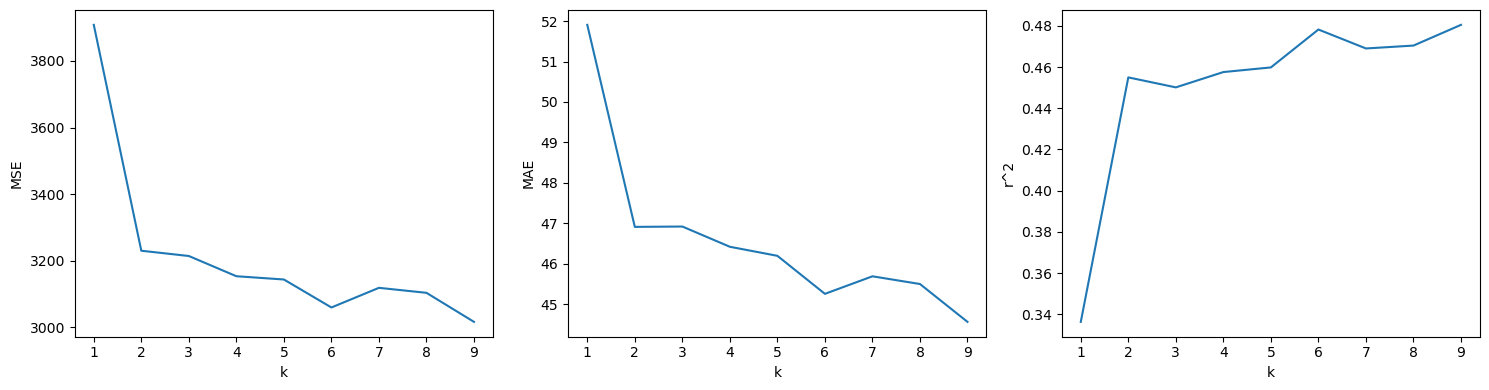


 ----- Final model with optimal selection of number of features -----
Selected features:  ['x0' 'x1' 'x2' 'x3' 'x4' 'x5' 'x7' 'x8' 'x9']
Model coefficients:  [  -8.95151061 -241.16056721  518.71569725  323.35644231 -619.77326006
  354.63165339  126.2650948   692.82455653   68.45594372]
Model intercept:  152.133484162896


In [13]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn import linear_model
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, r_regression

# Import Diabetes dataset
diabetes = datasets.load_diabetes()
x = diabetes.data
y = diabetes.target
features = diabetes.feature_names
n_features = len(features)
n_feats = [1, 2, 3, 4, 5, 6, 7, 8, 9]

mse_nfeat = []
mae_nfeat = []
r2_nfeat = []
for n_feat in n_feats:
    print('---- n features =', n_feat)
    
    mse_cv = []
    mae_cv = []
    r2_cv = []

    kf = KFold(n_splits=5, shuffle = True)

    for train_index, test_index in kf.split(x):
    
        # Training phase
        x_train = x[train_index, :]
        y_train = y[train_index]     
        
        fselection_cv = SelectKBest(r_regression, k = n_feat)
        fselection_cv.fit(x_train, y_train)
        x_train = fselection_cv.transform(x_train)

        regr_cv = linear_model.LinearRegression()
        regr_cv.fit(x_train, y_train)

        # Test phase
        x_test = fselection_cv.transform(x[test_index, :])
        y_test = y[test_index]
        y_pred = regr_cv.predict(x_test)
    
        mse_i = mean_squared_error(y_test, y_pred)
        mse_cv.append(mse_i)
    
        mae_i = mean_absolute_error(y_test, y_pred)
        mae_cv.append(mae_i)

        r2_i = r2_score(y_test, y_pred)    
        r2_cv.append(r2_i)      
    

    mse = np.average(mse_cv)
    mse_nfeat.append(mse)
    
    mae = np.average(mae_cv)
    mae_nfeat.append(mae)
    
    r2 = np.average(r2_cv)
    r2_nfeat.append(r2)
    
    print('MSE:', mse, '  MAE:', mae,'  R^2:', r2)

opt_index = np.argmin(mse_nfeat)
opt_features = n_feats[opt_index]
print("Optimal number of features: ", opt_features)

fig, axs = plt.subplots(1, 3, figsize=(15, 4), tight_layout=True)
axs[0].plot(n_feats, mse_nfeat)
axs[0].set_xlabel("k")
axs[0].set_ylabel("MSE")

axs[1].plot(n_feats, mae_nfeat)
axs[1].set_xlabel("k")
axs[1].set_ylabel("MAE")

axs[2].plot(n_feats, r2_nfeat)
axs[2].set_xlabel("k")
axs[2].set_ylabel("r^2")

plt.show()

# Fit model with optimal number of features
print("\n ----- Final model with optimal selection of number of features -----")

regr = linear_model.LinearRegression()
fselection = SelectKBest(r_regression, k = opt_features)
fselection.fit(x, y)

print("Selected features: ", fselection.get_feature_names_out())

x_transformed = fselection.transform(x)
regr.fit(x_transformed, y)
print("Model coefficients: ", regr.coef_)
print("Model intercept: ", regr.intercept_)
